In [1]:
from bioinfokit.analys import gff
%load_ext rpy2.ipython
import matplotlib.pyplot as plt
from rpy2.robjects import r, pandas2ri
import pandas as pd
from bioinfokit.analys import norm, get_data
import numpy as np
from matplotlib_venn import venn2
from matplotlib_venn import venn3
from io import StringIO

During startup - Warning messages:
1: Setting LC_COLLATE failed, using "C" 
2: Setting LC_TIME failed, using "C" 
3: Setting LC_MESSAGES failed, using "C" 
4: Setting LC_MONETARY failed, using "C" 
5: Setting LC_PAPER failed, using "C" 
6: Setting LC_MEASUREMENT failed, using "C" 


In [2]:
# # Lista dei dataset e dei nomi dei tessuti
# tissue_files = {
#     "brain": 'TPM_Norm_1_reads_filt_averaged_exon_lengths>150_by_quantile_brain.csv',
#     "gonads": 'TPM_Norm_1_reads_filt_averaged_exon_lengths>150_by_quantile_gonads.csv',
#     "miscellaneous": 'TPM_Norm_1_reads_filt_averaged_exon_lengths>150_by_quantile_miscellaneous.csv'
# }

# for tissue, file in tissue_files.items():
#     # Caricare il file
#     df = pd.read_csv(file, sep=",")
    
#     # Selezionare le colonne di interesse >>> non necessario subsettare le colonne >>> lascio tutto il df
#     #df_subset = df[['average_TPM', 'exon_length']]
    
#     df_subset_sorted = df.sort_values(by='average_TPM', ascending=True)
    
#     # Creare i bin per average_TPM con intervalli di 0.1
#     df_subset_sorted['TPM_bin'] = pd.cut(df_subset_sorted['average_TPM'], 
#                                         bins=[x * 0.1 for x in range(0, int(df_subset_sorted['average_TPM'].max() * 10) + 2)], 
#                                         right=False)
    
#     # Calcolare la somma cumulativa per Low fino a 7 Mb
#     df_subset_sorted['cumsum_low'] = df_subset_sorted['exon_length'].cumsum()
#     df_subset_sorted.loc[df_subset_sorted['cumsum_low'] > 7_000_000, 'cumsum_low'] = np.nan
#     df_low = df_subset_sorted[df_subset_sorted['cumsum_low'].notna()].copy()
#     df_low['category'] = 'Low'
    
#     # Ordinare per High e calcolare la somma cumulativa fino a 7 Mb
#     df_subset_sorted_desc = df_subset_sorted.sort_values(by='average_TPM', ascending=False)
#     df_subset_sorted_desc['cumsum_high'] = df_subset_sorted_desc['exon_length'].cumsum()
#     df_subset_sorted_desc.loc[df_subset_sorted_desc['cumsum_high'] > 7_000_000, 'cumsum_high'] = np.nan
#     df_high = df_subset_sorted_desc[df_subset_sorted_desc['cumsum_high'].notna()].copy()
#     df_high['category'] = 'High'
    
#     # Identificare gli esoni che non sono né in Low né in High e calcolare la somma cumulativa per Mid
#     df_mid = df_subset_sorted[~df_subset_sorted.index.isin(df_low.index) & ~df_subset_sorted.index.isin(df_high.index)].copy()
#     df_mid['category'] = 'Mid'
#     df_mid['cumsum_mid'] = df_mid['exon_length'].cumsum()
    
#     # Unire i tre dataset
#     df_combined = pd.concat([df_low, df_high, df_mid])
#     df_combined.to_csv(f"{tissue}_combined.csv", index=False)
    
#     # Raggruppare per i bin e sommare la lunghezza degli esoni in Mb per ciascuna categoria
#     bin_summary_log = df_subset_sorted.groupby('TPM_bin')['exon_length'].sum().reset_index()
#     bin_summary_log['exon_length'] = bin_summary_log['exon_length'] / 1_000_000  # Convertire in Mb
    
#     # Creare un asse x con i valori medi dei bin per la scala logaritmica
#     bin_labels = bin_summary_log['TPM_bin'].apply(lambda x: x.left).astype(float)
#     x_values = np.array(bin_labels) + 0.05  # Centrare i bin
    
#     # Separare le categorie per il plot
#     low_bins = df_combined[df_combined['category'] == 'Low'].groupby('TPM_bin')['exon_length'].sum().reset_index()
#     high_bins = df_combined[df_combined['category'] == 'High'].groupby('TPM_bin')['exon_length'].sum().reset_index()
#     mid_bins = df_combined[df_combined['category'] == 'Mid'].groupby('TPM_bin')['exon_length'].sum().reset_index()
    
#     low_bins['TPM_bin'] = low_bins['TPM_bin'].apply(lambda x: x.left).astype(float)
#     high_bins['TPM_bin'] = high_bins['TPM_bin'].apply(lambda x: x.left).astype(float)
#     mid_bins['TPM_bin'] = mid_bins['TPM_bin'].apply(lambda x: x.left).astype(float)
    
#     low_bins['exon_length'] = low_bins['exon_length'] / 1_000_000
#     high_bins['exon_length'] = high_bins['exon_length'] / 1_000_000
#     mid_bins['exon_length'] = mid_bins['exon_length'] / 1_000_000
    
#     # Creare il grafico
#     plt.figure(figsize=(15, 9))
#     plt.bar(x_values, bin_summary_log['exon_length'], width=0.08, align='center', alpha=0.7, color='green', label='Mid')
#     plt.bar(low_bins['TPM_bin'] + 0.05, low_bins['exon_length'], width=0.08, align='center', alpha=0.7, color='blue', label='Low')
#     plt.bar(high_bins['TPM_bin'] + 0.05, high_bins['exon_length'], width=0.08, align='center', alpha=0.7, color='red', label='High')
#     plt.xscale('log')  # Scala logaritmica
#     plt.xlabel('TPM Bin (log scale)')
#     plt.ylabel('Cumulative exon Length (Mb)')
#     plt.title(f'Total Exon Length per TPM Bin - {tissue.capitalize()}')
#     plt.legend()
#     plt.grid(True, which="both", linestyle="--", linewidth=0.5)
#     plt.savefig(f"{tissue}_TPM_plot.pdf")
#     plt.show()


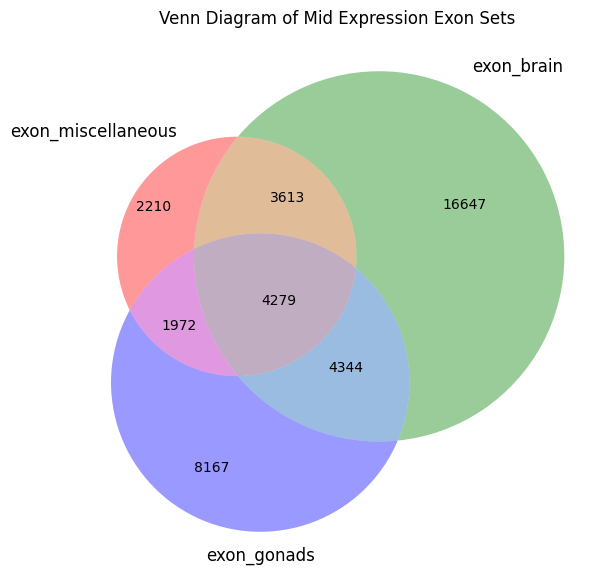

In [3]:
# Lista dei dataset e dei nomi dei tessuti
tissue_files = {
    "brain": 'TPM_Norm_1_reads_filt_averaged_exon_lengths>150_by_quantile_brain.csv',
    "gonads": 'TPM_Norm_1_reads_filt_averaged_exon_lengths>150_by_quantile_gonads.csv',
    "miscellaneous": 'TPM_Norm_1_reads_filt_averaged_exon_lengths>150_by_quantile_miscellaneous.csv'
}

mid_exon_sets = {}

def extract_mid_exon_coords(mid_exon_sets):
    annotation = pd.read_csv('../BoPac.tsebra.pref_braker1_exon_number_bypy_clean_coordinates.bed', header=None, sep='\t')
    annotation = annotation.rename(columns={0: "scaffold", 1: "start", 2: "end", 3: "exon"})
    
    # Unire gli esoni Mid di tutti i tessuti
    mid_exp_exon = pd.concat([pd.Series(list(mid_exon_sets[tissue])) for tissue in mid_exon_sets]).drop_duplicates().reset_index(drop=True)
    
    # Associare le coordinate agli esoni
    mid_exp_exon_coord = pd.merge(mid_exp_exon.to_frame(name='exon'), annotation, on="exon")
    
    # Calcolare la lunghezza dell'esone
    mid_exp_exon_coord['exon_length'] = mid_exp_exon_coord['end'] - mid_exp_exon_coord['start']
    
    # Salvare il file
    mid_exp_exon_coord.to_csv('mid_exp_exon_coord-lenght.csv', index=False)
    
    # Eliminare duplicati basati su scaffold, start, end
    mid_exp_exon_coord_unique = mid_exp_exon_coord.drop_duplicates(subset=["scaffold", "start", "end"])
    mid_exp_exon_coord_unique.to_csv('mid_exp_UNIQUE_exon_coord-lenght.csv', index=False)
    
    return mid_exp_exon_coord_unique

for tissue, file in tissue_files.items():
    # Caricare il file
    df = pd.read_csv(file, sep=",")
    
    # Ordinare per average_TPM
    df_subset_sorted = df.sort_values(by='average_TPM', ascending=True)
    
    # Creare i bin per average_TPM con intervalli di 0.1
    df_subset_sorted['TPM_bin'] = pd.cut(df_subset_sorted['average_TPM'], 
                                        bins=[x * 0.1 for x in range(0, int(df_subset_sorted['average_TPM'].max() * 10) + 2)], 
                                        right=False)
    
    # Calcolare la somma cumulativa per Low fino a 7 Mb
    df_subset_sorted['cumsum_low'] = df_subset_sorted['exon_length'].cumsum()
    df_subset_sorted.loc[df_subset_sorted['cumsum_low'] > 7_000_000, 'cumsum_low'] = np.nan
    df_low = df_subset_sorted[df_subset_sorted['cumsum_low'].notna()].copy()
    df_low['category'] = 'Low'
    
    # Ordinare per High e calcolare la somma cumulativa fino a 7 Mb
    df_subset_sorted_desc = df_subset_sorted.sort_values(by='average_TPM', ascending=False)
    df_subset_sorted_desc['cumsum_high'] = df_subset_sorted_desc['exon_length'].cumsum()
    df_subset_sorted_desc.loc[df_subset_sorted_desc['cumsum_high'] > 7_000_000, 'cumsum_high'] = np.nan
    df_high = df_subset_sorted_desc[df_subset_sorted_desc['cumsum_high'].notna()].copy()
    df_high['category'] = 'High'
    
    # Identificare gli esoni che non sono né in Low né in High e calcolare la somma cumulativa per Mid
    df_mid = df_subset_sorted[~df_subset_sorted.index.isin(df_low.index) & ~df_subset_sorted.index.isin(df_high.index)].copy()
    df_mid['category'] = 'Mid'
    df_mid['cumsum_mid'] = df_mid['exon_length'].cumsum()
    
    # Salvare gli esoni Mid per ogni tessuto
    mid_exon_sets[tissue] = set(df_mid['exon'])
    
    # Unire i tre dataset
    df_combined = pd.concat([df_low, df_high, df_mid])
    df_combined.to_csv(f"{tissue}_combined.csv", index=False)

# # Creare il diagramma di Venn
# plt.figure(figsize=(10,7))
# venn = venn3([mid_exon_sets['miscellaneous'], mid_exon_sets['brain'], mid_exon_sets['gonads']],
#              ('exon_miscellaneous', 'exon_brain', 'exon_gonads'))
# plt.title("Venn Diagram of Mid Expression Exon Sets")
# plt.savefig("Venn_Diagram_Mid_Expression_Exon_Sets.pdf")
# plt.show()

# Estrarre le coordinate degli esoni Mid
mid_exp_exon_coord_unique = extract_mid_exon_coords(mid_exon_sets)

# Funzione per aggiornare la colonna in base alla presenza nel tessuto
def update_tissue_column(df, tissue_df, tissue_name, column_name):
    df[column_name] = df['exon'].isin(tissue_df['exon']).replace({True: tissue_name, False: ''})
    return df

for tissue in tissue_files:
    mid_exp_exon_coord_unique = update_tissue_column(mid_exp_exon_coord_unique, pd.DataFrame(mid_exon_sets[tissue], columns=['exon']), tissue, f'in_{tissue}')

# Funzione per concatenare i nomi dei tessuti presenti
def concatenate_non_na(row):
    parts = [row['exon']]
    if not pd.isna(row.get('in_miscellaneous')):
        parts.append(row['in_miscellaneous'])
    if not pd.isna(row.get('in_brain')):
        parts.append(row['in_brain'])
    if not pd.isna(row.get('in_gonads')):
        parts.append(row['in_gonads'])
    return '|'.join(parts)

# Creare la colonna exon_tissue
mid_exp_exon_coord_unique['exon_tissue'] = mid_exp_exon_coord_unique.apply(concatenate_non_na, axis=1)

# Rimuovere le colonne in_miscellaneous, in_brain, in_gonads
mid_exp_exon_coord_unique.drop(columns=['in_miscellaneous', 'in_brain', 'in_gonads'], inplace=True)

# Salvare il file aggiornato
mid_exp_exon_coord_unique.to_csv('Mid_exp_UNIQUE_exon_coord-length_tissue.csv', index=False)
mid_exp_exon_coord_unique.to_csv('Mid_exp_UNIQUE_exon_coord-length_tissue.bed', index=False, sep="\t")

# Added strand info and removed columns not useful to bed file

In [4]:

annotation_strand_type = pd.read_csv('../BoPac.tsebra.pref_braker1_exon_number_bypy_clean_strand_type.gtf', sep="\t")
bed_file_mid = pd.read_csv('Mid_exp_UNIQUE_exon_coord-length_tissue.bed', sep="\t")

bed_file_mid_strand_type = pd.merge(bed_file_mid, annotation_strand_type, on="exon")

bed_file_mid_strand_type["info_strand"]=bed_file_mid_strand_type["exon_tissue"] + "|" + bed_file_mid_strand_type["strand"]

bed_file_mid_strand_type.drop(bed_file_mid_strand_type.columns[[0, 4, 5, 6]], axis=1, inplace=True)


In [5]:
bed_file_mid_strand_type.to_csv('Mid_exp_UNIQUE_coord_tissue_strand_type.bed', index=False, sep="\t", header=False)

In [6]:
!awk '{gsub(/\|\|\|/, "|"); gsub(/\|\|/, "|"); print}' Mid_exp_UNIQUE_coord_tissue_strand_type.bed > Mid_exp_UNIQUE_coord_tissue_strand_type_type_clean.bed

# Merging of overlapping exonic regions


In [7]:
!cat Mid_exp_UNIQUE_coord_tissue_strand_type_type_clean.bed | sort -k1,1 -k2n | bedtools merge -c 4 -o collapse > Mid_exp_UNIQUE_coord_tissue_strand_type_merged.bed

In [8]:
cat Mid_exp_UNIQUE_coord_tissue_strand_type_merged.bed | sort -k1,1 -k2n | bedtools merge -c 4 -o collapse | awk '{sum+=$3-$2-1} END {print sum}'

8036787


# Removal of regions of high- and low-expressing exons

In [9]:
!bedtools subtract -a Mid_exp_UNIQUE_coord_tissue_strand_type_merged.bed \
                  -b ../only_high_exp_UNIQUE_exon_coord_tissue_strand_type_merged_clean_noTE.bed ../only_low_exp_UNIQUE_exon_coord_tissue_strand_type_merged_clean_noTE.bed \
                  > Mid_exp_filtered.bed

In [2]:
!cat Mid_exp_filtered.bed | sort -k1,1 -k2n | bedtools merge -c 4 -o collapse | awk '{sum+=$3-$2-1} END {print sum}'

2593373


In [3]:
!cat Mid_exp_filtered_noTE_150bp.bed | sort -k1,1 -k2n | bedtools merge -c 4 -o collapse | awk '{sum+=$3-$2-1} END {print sum}'

2591421
